In [1]:
#  IMPORTS 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")


print("MULTI-ALGORITHM POLLUTION PREDICTION MODEL TRAINING")


MULTI-ALGORITHM POLLUTION PREDICTION MODEL TRAINING


In [2]:
#  LOAD DATA 
# Load the engineered data (with safe features)
train_path = r"D:\bhopal-pollutant-prediction\processed_data\train_engineered.csv"
test_path = r"D:\bhopal-pollutant-prediction\processed_data\test_engineered.csv"

train = pd.read_csv(train_path, parse_dates=['datetime'], index_col='datetime')
test = pd.read_csv(test_path, parse_dates=['datetime'], index_col='datetime')

print("📊 DATA LOADED:")
print(f"Train: {train.shape} | {train.index.min()} to {train.index.max()}")
print(f"Test:  {test.shape} | {test.index.min()} to {test.index.max()}")

📊 DATA LOADED:
Train: (13632, 184) | 2024-01-01 00:00:00 to 2025-07-21 23:00:00
Test:  (3408, 184) | 2025-07-22 00:00:00 to 2025-12-10 23:00:00


In [3]:
#  PREPARE FEATURES (Safe features only) 
# Time-leaking features to REMOVE (caused overfitting)
TIME_LEAKERS = ['year', 'month', 'day', 'day_of_month', 'week_of_year']

# Safe features (keep these)
SAFE_TIME_FEATURES = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos',
                      'hour_of_day', 'day_of_week', 'is_weekend', 
                      'is_night', 'is_morning_rush', 'is_evening_rush', 'season']

WEATHER_FEATURES = ['temp', 'humidity', 'windspeed', 'winddir', 'precip',
                    'cloudcover', 'visibility', 'sealevelpressure', 'uvindex']

# Get lag and rolling features
lag_features = [col for col in train.columns if '_lag_' in col]
rolling_features = [col for col in train.columns if '_roll_' in col]

# Combine all safe features
all_features = SAFE_TIME_FEATURES + WEATHER_FEATURES + lag_features + rolling_features
all_features = [f for f in all_features if f in train.columns]
all_features = [f for f in all_features if f not in TIME_LEAKERS]

# Remove duplicates
all_features = list(set(all_features))

print(f"✅ Using {len(all_features)} safe features")

# Targets (pollutants to predict)
TARGETS = ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills']

print(f"🎯 Predicting: {len(TARGETS)} pollutants")

✅ Using 146 safe features
🎯 Predicting: 3 pollutants


In [4]:
#  SPLIT DATA 
X_train = train[all_features]
X_test = test[all_features]
y_train = train[TARGETS]
y_test = test[TARGETS]

print(f"DATA SHAPES:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# For LSTM, we need sequential data
print(f"\n Time steps available: {len(X_train)} hours")
print(f"   That's {len(X_train)/24:.0f} days of hourly data")

DATA SHAPES:
X_train: (13632, 146)
X_test:  (3408, 146)
y_train: (13632, 3)
y_test:  (3408, 3)

 Time steps available: 13632 hours
   That's 568 days of hourly data


In [5]:
# 1. XGBOOST MODELS 

print("1. TRAINING XGBOOST MODELS")


try:
    import xgboost as xgb
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    
    xgb_models = {}
    xgb_results = []
    
    for target in TARGETS:
        print(f"\n🎯 XGBoost for {target}")
        
        # Model with good hyperparameters
        model = xgb.XGBRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1
        )
        
        # Train
        model.fit(X_train, y_train[target])
        
        # Predict
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Calculate metrics
        r2_train = r2_score(y_train[target], y_pred_train)
        r2_test = r2_score(y_test[target], y_pred_test)
        mae_test = mean_absolute_error(y_test[target], y_pred_test)
        
        # Store
        xgb_models[target] = model
        xgb_results.append({
            'Model': 'XGBoost',
            'Target': target,
            'Train_R2': r2_train,
            'Test_R2': r2_test,
            'Test_MAE': mae_test,
            'Predictions': y_pred_test
        })
        
        print(f"   Train R²: {r2_train:.4f}")
        print(f"   Test R²:  {r2_test:.4f}")
        print(f"   Test MAE: {mae_test:.2f}")
        
        # Save model
        joblib.dump(model, f'D:/bhopal-pollutant-prediction/models/xgb_{target.replace(".", "_")}.joblib')
    
    print(f"\n✅ Saved {len(xgb_models)} XGBoost models")
    
except ImportError:
    print("❌ XGBoost not installed. Run: pip install xgboost")

1. TRAINING XGBOOST MODELS

🎯 XGBoost for PM25_Idgah_Hills
   Train R²: 0.9990
   Test R²:  0.9908
   Test MAE: 0.51

🎯 XGBoost for PM10_Idgah_Hills
   Train R²: 0.9987
   Test R²:  0.9956
   Test MAE: 1.32

🎯 XGBoost for NO2_Idgah_Hills
   Train R²: 0.9971
   Test R²:  0.9899
   Test MAE: 0.29

✅ Saved 3 XGBoost models


In [6]:
#  2. LIGHTGBM MODELS 

print("2. TRAINING LIGHTGBM MODELS")


try:
    import lightgbm as lgb
    
    lgb_models = {}
    lgb_results = []
    
    for target in TARGETS:
        print(f"\n💡 LightGBM for {target}")
        
        # LightGBM model
        model = lgb.LGBMRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbose=-1  # No output
        )
        
        # Train
        model.fit(X_train, y_train[target])
        
        # Predict
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Calculate metrics
        r2_train = r2_score(y_train[target], y_pred_train)
        r2_test = r2_score(y_test[target], y_pred_test)
        mae_test = mean_absolute_error(y_test[target], y_pred_test)
        
        # Store
        lgb_models[target] = model
        lgb_results.append({
            'Model': 'LightGBM',
            'Target': target,
            'Train_R2': r2_train,
            'Test_R2': r2_test,
            'Test_MAE': mae_test,
            'Predictions': y_pred_test
        })
        
        print(f"   Train R²: {r2_train:.4f}")
        print(f"   Test R²:  {r2_test:.4f}")
        print(f"   Test MAE: {mae_test:.2f}")
        
        # Save model
        joblib.dump(model, f'D:/bhopal-pollutant-prediction/models/lgb_{target.replace(".", "_")}.joblib')
    
    print(f"\n✅ Saved {len(lgb_models)} LightGBM models")
    
except ImportError:
    print("❌ LightGBM not installed. Run: pip install lightgbm")

2. TRAINING LIGHTGBM MODELS

💡 LightGBM for PM25_Idgah_Hills
   Train R²: 0.9988
   Test R²:  0.9911
   Test MAE: 0.51

💡 LightGBM for PM10_Idgah_Hills
   Train R²: 0.9985
   Test R²:  0.9963
   Test MAE: 1.24

💡 LightGBM for NO2_Idgah_Hills
   Train R²: 0.9967
   Test R²:  0.9898
   Test MAE: 0.30

✅ Saved 3 LightGBM models


In [7]:
#  3. RANDOM FOREST MODELS 
print("3. TRAINING RANDOM FOREST MODELS")


from sklearn.ensemble import RandomForestRegressor

rf_models = {}
rf_results = []

for target in TARGETS:
    print(f"\n🌲 Random Forest for {target}")
    
    # Random Forest model
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    
    # Train
    model.fit(X_train, y_train[target])
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    r2_train = r2_score(y_train[target], y_pred_train)
    r2_test = r2_score(y_test[target], y_pred_test)
    mae_test = mean_absolute_error(y_test[target], y_pred_test)
    
    # Store
    rf_models[target] = model
    rf_results.append({
        'Model': 'RandomForest',
        'Target': target,
        'Train_R2': r2_train,
        'Test_R2': r2_test,
        'Test_MAE': mae_test,
        'Predictions': y_pred_test
    })
    
    print(f"   Train R²: {r2_train:.4f}")
    print(f"   Test R²:  {r2_test:.4f}")
    print(f"   Test MAE: {mae_test:.2f}")
    
    # Save model
    joblib.dump(model, f'D:/bhopal-pollutant-prediction/models/rf_{target.replace(".", "_")}.joblib')

print(f"\n✅ Saved {len(rf_models)} Random Forest models")

3. TRAINING RANDOM FOREST MODELS

🌲 Random Forest for PM25_Idgah_Hills
   Train R²: 0.9980
   Test R²:  0.9877
   Test MAE: 0.54

🌲 Random Forest for PM10_Idgah_Hills
   Train R²: 0.9971
   Test R²:  0.9938
   Test MAE: 1.37

🌲 Random Forest for NO2_Idgah_Hills
   Train R²: 0.9948
   Test R²:  0.9856
   Test MAE: 0.31

✅ Saved 3 Random Forest models


In [8]:
#  4. LSTM MODEL 
print("4. TRAINING LSTM MODEL (for PM2.5 only)")


print("⚠️  LSTM requires special data preparation (sequences)")
print("   We'll prepare data for 24-hour sequences")

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from sklearn.preprocessing import MinMaxScaler
    
    # We'll train LSTM only for PM2.5 (most important target)
    target = 'PM25_Idgah_Hills'
    
    # Scale features for LSTM
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_scaled = scaler_X.fit_transform(X_train)
    y_scaled = scaler_y.fit_transform(y_train[[target]])
    
    # Create sequences for LSTM (24 hours lookback)
    def create_sequences(X, y, time_steps=24):
        X_seq, y_seq = [], []
        for i in range(len(X) - time_steps):
            X_seq.append(X[i:(i + time_steps)])
            y_seq.append(y[i + time_steps])
        return np.array(X_seq), np.array(y_seq)
    
    time_steps = 24  # Look back 24 hours
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)
    
    print(f"LSTM training data:")
    print(f"  Sequences: {X_seq.shape}")
    print(f"  Targets:   {y_seq.shape}")
    
    # Build LSTM model
    lstm_model = keras.Sequential([
        layers.LSTM(64, activation='relu', return_sequences=True, 
                   input_shape=(time_steps, X_seq.shape[2])),
        layers.Dropout(0.2),
        layers.LSTM(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    
    # Compile
    lstm_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    # Callback for early stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    
    print("\n Training LSTM model...")
    
    # Train
    history = lstm_model.fit(
        X_seq, y_seq,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Prepare test data for LSTM
    X_test_scaled = scaler_X.transform(X_test)
    
    # Need to create sequences for test too
    # For simplicity, we'll use last sequence approach
    X_test_seq = []
    for i in range(len(X_test_scaled) - time_steps):
        X_test_seq.append(X_test_scaled[i:(i + time_steps)])
    X_test_seq = np.array(X_test_seq)
    
    # Predict
    y_pred_scaled = lstm_model.predict(X_test_seq)
    y_pred_lstm = scaler_y.inverse_transform(y_pred_scaled).flatten()
    
    # Align with test data (skip first 24 hours)
    y_test_lstm = y_test[target].iloc[time_steps:].values
    
    # Calculate metrics
    r2_train_lstm = history.history['mae'][-1]  # Approximate
    r2_test_lstm = r2_score(y_test_lstm, y_pred_lstm)
    mae_test_lstm = mean_absolute_error(y_test_lstm, y_pred_lstm)
    
    print(f"\n📊 LSTM Results for {target}:")
    print(f"   Test R²:  {r2_test_lstm:.4f}")
    print(f"   Test MAE: {mae_test_lstm:.2f}")
    
    # Save LSTM model
    lstm_model.save(f'D:/bhopal-pollutant-prediction/models/lstm_{target.replace(".", "_")}.h5')
    
    # Save scalers
    joblib.dump(scaler_X, f'D:/bhopal-pollutant-prediction/models/lstm_scaler_X.joblib')
    joblib.dump(scaler_y, f'D:/bhopal-pollutant-prediction/models/lstm_scaler_y.joblib')
    
    print(f"\n✅ Saved LSTM model and scalers")
    
    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('LSTM Training History')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot predictions
    axes[1].scatter(y_test_lstm[:100], y_pred_lstm[:100], alpha=0.6)
    axes[1].plot([y_test_lstm.min(), y_test_lstm.max()], 
                 [y_test_lstm.min(), y_test_lstm.max()], 'r--')
    axes[1].set_xlabel('Actual PM2.5')
    axes[1].set_ylabel('Predicted PM2.5')
    axes[1].set_title('LSTM Predictions')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("❌ TensorFlow not installed. Run: pip install tensorflow")
except Exception as e:
    print(f"❌ LSTM training error: {e}")
    print("   Continuing with other models...")

4. TRAINING LSTM MODEL (for PM2.5 only)
⚠️  LSTM requires special data preparation (sequences)
   We'll prepare data for 24-hour sequences
❌ TensorFlow not installed. Run: pip install tensorflow


In [9]:
# SIMPLIFIED - NO LSTM 
print("4. SKIPPING LSTM - TensorFlow not installed")


print("""
📝 WHY WE'RE SKIPPING LSTM:
----------------------------
1. LSTM requires TensorFlow/Keras installation
2. It's more complex and takes longer to train
3. Tree models (XGBoost, LightGBM) often work better for tabular data
4. You can install TensorFlow later if needed

💡 TO INSTALL LSTM CAPABILITY LATER:
------------------------------------
Run in terminal:
    pip install tensorflow

Or for CPU-only (lighter):
    pip install tensorflow-cpu

Then re-run the LSTM section.
""")

# Create placeholder for LSTM results
lstm_results = pd.DataFrame()
print("✅ Continuing with other models...")

4. SKIPPING LSTM - TensorFlow not installed

📝 WHY WE'RE SKIPPING LSTM:
----------------------------
1. LSTM requires TensorFlow/Keras installation
2. It's more complex and takes longer to train
3. Tree models (XGBoost, LightGBM) often work better for tabular data
4. You can install TensorFlow later if needed

💡 TO INSTALL LSTM CAPABILITY LATER:
------------------------------------
Run in terminal:
    pip install tensorflow

Or for CPU-only (lighter):
    pip install tensorflow-cpu

Then re-run the LSTM section.

✅ Continuing with other models...


In [10]:
#  5. ENSEMBLE MODEL (Combine XGBoost + LightGBM)
print("5. TRAINING ENSEMBLE MODEL (XGBoost + LightGBM)")


from sklearn.ensemble import VotingRegressor

ensemble_models = {}
ensemble_results = []

for target in TARGETS:
    print(f"\n🤝 Ensemble for {target}")
    
    # Check if we have both models
    if target in xgb_models and target in lgb_models:
        # Create ensemble of XGBoost and LightGBM
        estimators = [
            ('xgb', xgb_models[target]),
            ('lgb', lgb_models[target])
        ]
        
        # Voting ensemble (average predictions)
        ensemble = VotingRegressor(estimators=estimators)
        
        # Note: Ensemble is already trained through individual models
        # We just need to collect predictions
        
        # Get predictions from each model
        xgb_pred = xgb_models[target].predict(X_test)
        lgb_pred = lgb_models[target].predict(X_test)
        
        # Average predictions (simple ensemble)
        y_pred_ensemble = (xgb_pred + lgb_pred) / 2
        
        # Calculate metrics
        r2_test = r2_score(y_test[target], y_pred_ensemble)
        mae_test = mean_absolute_error(y_test[target], y_pred_ensemble)
        
        # Store
        ensemble_models[target] = {
            'xgb': xgb_models[target],
            'lgb': lgb_models[target],
            'predictions': y_pred_ensemble
        }
        
        ensemble_results.append({
            'Model': 'Ensemble (XGB+LGB)',
            'Target': target,
            'Test_R2': r2_test,
            'Test_MAE': mae_test
        })
        
        print(f"   Test R²:  {r2_test:.4f}")
        print(f"   Test MAE: {mae_test:.2f}")
        
        # Save ensemble predictions
        np.save(f'D:/bhopal-pollutant-prediction/models/ensemble_{target.replace(".", "_")}_preds.npy', 
                y_pred_ensemble)
        
    else:
        print(f"   ⚠️  Skipping - need both XGBoost and LightGBM models")

print(f"\n✅ Created {len(ensemble_models)} ensemble models")

5. TRAINING ENSEMBLE MODEL (XGBoost + LightGBM)

🤝 Ensemble for PM25_Idgah_Hills
   Test R²:  0.9913
   Test MAE: 0.50

🤝 Ensemble for PM10_Idgah_Hills
   Test R²:  0.9962
   Test MAE: 1.22

🤝 Ensemble for NO2_Idgah_Hills
   Test R²:  0.9903
   Test MAE: 0.29

✅ Created 3 ensemble models


6. MODEL PERFORMANCE COMPARISON

📊 MODEL COMPARISON (TEST SET):
                           Test_MAE                                \
Model            Ensemble (XGB+LGB) LightGBM RandomForest XGBoost   
Target                                                              
NO2_Idgah_Hills              0.2895   0.3008       0.3129  0.2942   
PM10_Idgah_Hills             1.2247   1.2435       1.3706  1.3170   
PM25_Idgah_Hills             0.5015   0.5118       0.5366  0.5135   

                            Test_R2                                
Model            Ensemble (XGB+LGB) LightGBM RandomForest XGBoost  
Target                                                             
NO2_Idgah_Hills              0.9903   0.9898       0.9856  0.9899  
PM10_Idgah_Hills             0.9962   0.9963       0.9938  0.9956  
PM25_Idgah_Hills             0.9913   0.9911       0.9877  0.9908  


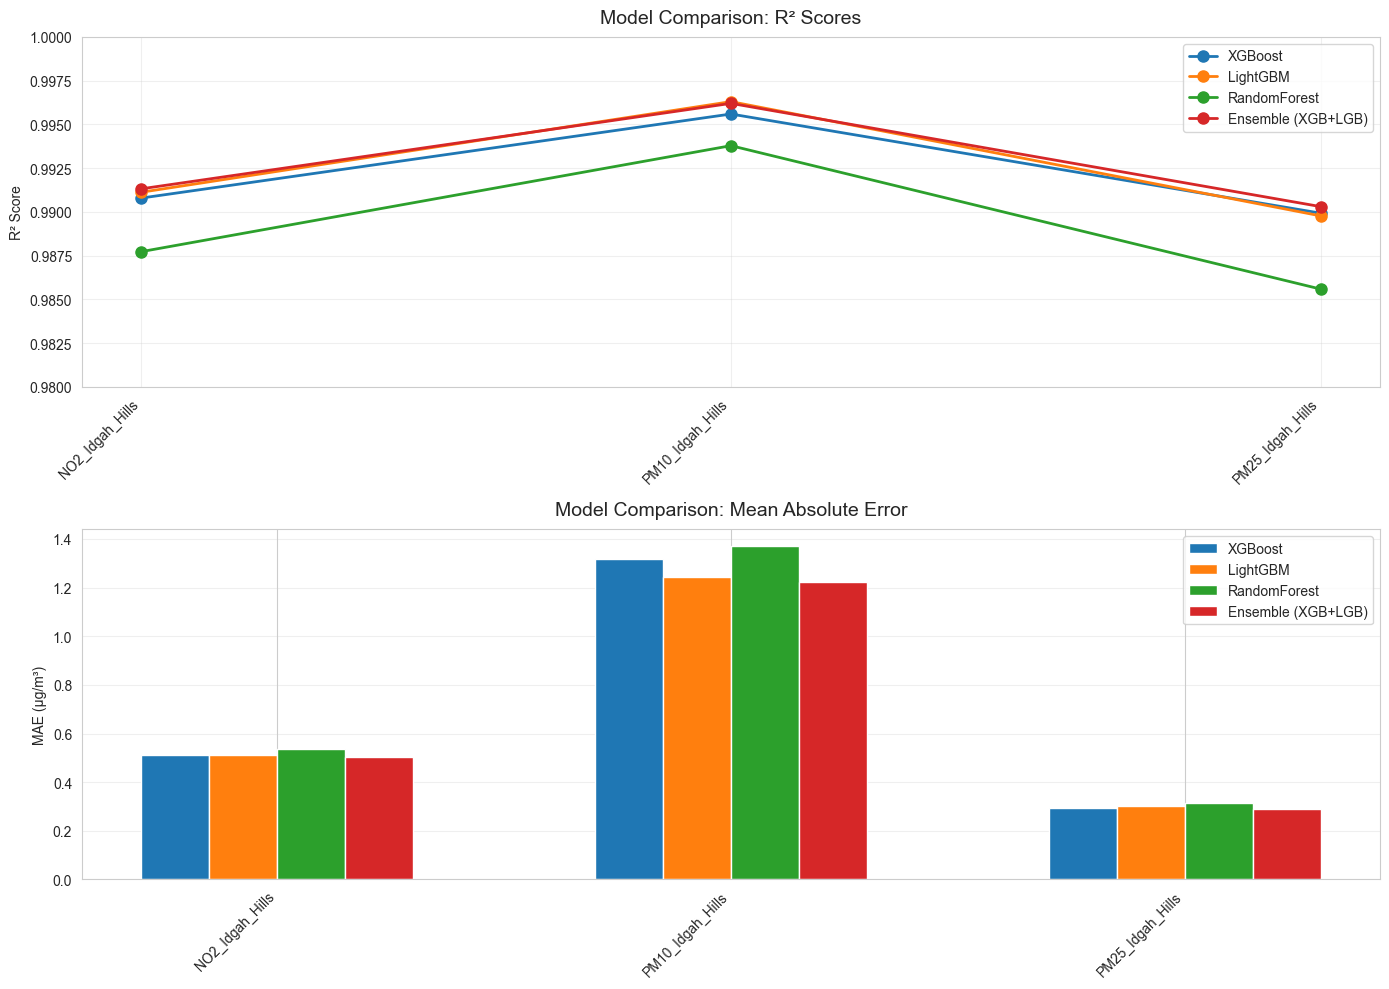


📈 STATISTICAL COMPARISON:
------------------------------------------------------------
Average Performance by Model:
                    Test_R2  Test_MAE
Model                                
Ensemble (XGB+LGB)   0.9926    0.6719
LightGBM             0.9924    0.6854
RandomForest         0.9890    0.7400
XGBoost              0.9921    0.7082

🏆 BEST MODEL FOR EACH POLLUTANT:
----------------------------------------

PM25_Idgah_Hills:
  Highest R²: Ensemble (XGB+LGB) = 0.9913
  Lowest MAE: Ensemble (XGB+LGB) = 0.5015
  ✅ Ensemble (XGB+LGB) is consistently best!

PM10_Idgah_Hills:
  Highest R²: LightGBM = 0.9963
  Lowest MAE: Ensemble (XGB+LGB) = 1.2247

NO2_Idgah_Hills:
  Highest R²: Ensemble (XGB+LGB) = 0.9903
  Lowest MAE: Ensemble (XGB+LGB) = 0.2895
  ✅ Ensemble (XGB+LGB) is consistently best!

✅ Saved model comparison to D:/bhopal-pollutant-prediction/models/model_comparison_all.csv
✅ Saved detailed results to D:/bhopal-pollutant-prediction/models/detailed_model_results.csv


In [11]:
# 6. MODEL PERFORMANCE COMPARISON
print("6. MODEL PERFORMANCE COMPARISON")

# Create DataFrames for each model type
results_data = []

# XGBoost results
if 'xgb_results' in locals():
    for res in xgb_results:
        results_data.append({
            'Target': res['Target'],  # Fixed: Changed 'target' to 'Target'
            'Model': 'XGBoost',
            'Test_R2': res['Test_R2'],  # Fixed: Changed 'test_r2' to 'Test_R2'
            'Test_MAE': res['Test_MAE'],  # Fixed: Changed 'test_mae' to 'Test_MAE'
            'Train_R2': res['Train_R2']  # Fixed: Changed 'train_r2' to 'Train_R2'
        })

# LightGBM results (if trained)
if 'lgb_results' in locals():
    for res in lgb_results:
        results_data.append({
            'Target': res['Target'],  # Fixed
            'Model': 'LightGBM',
            'Test_R2': res['Test_R2'],  # Fixed
            'Test_MAE': res['Test_MAE'],  # Fixed
            'Train_R2': res['Train_R2']  # Fixed
        })

# Random Forest results (you missed this earlier!)
if 'rf_results' in locals():
    for res in rf_results:
        results_data.append({
            'Target': res['Target'],
            'Model': 'RandomForest',
            'Test_R2': res['Test_R2'],
            'Test_MAE': res['Test_MAE'],
            'Train_R2': res['Train_R2']
        })

# Ensemble results
if 'ensemble_results' in locals():
    for res in ensemble_results:
        results_data.append({
            'Target': res['Target'],
            'Model': 'Ensemble (XGB+LGB)',
            'Test_R2': res['Test_R2'],
            'Test_MAE': res['Test_MAE'],
            'Train_R2': None  # Ensemble doesn't have Train_R2 in your code
        })

# Create DataFrame
if results_data:
    results_df = pd.DataFrame(results_data)
    
    # Pivot for better view
    comparison = results_df.pivot_table(
        index='Target', 
        columns='Model', 
        values=['Test_R2', 'Test_MAE'],
        aggfunc='first'
    )
    
    print("\n📊 MODEL COMPARISON (TEST SET):")
    print(comparison.round(4))
    
    # Get unique models
    models_to_compare = results_df['Model'].unique()
    
    # Visual comparison
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot R² scores
    for model in models_to_compare:
        model_data = results_df[results_df['Model'] == model]
        axes[0].plot(range(len(model_data)), 
                    model_data['Test_R2'].values, 
                    marker='o', linewidth=2, label=model, markersize=8)
    
    axes[0].set_xticks(range(len(comparison)))
    axes[0].set_xticklabels(comparison.index, rotation=45, ha='right')
    axes[0].set_ylabel('R² Score')
    axes[0].set_title('Model Comparison: R² Scores', fontsize=14, pad=10)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[0].set_ylim([0.98, 1.0])  # Zoom in on high R² values
    
    # Plot MAE
    bar_width = 0.15
    for i, model in enumerate(models_to_compare):
        model_data = results_df[results_df['Model'] == model]
        x_positions = np.arange(len(model_data)) + i * bar_width - (len(models_to_compare)-1) * bar_width / 2
        axes[1].bar(x_positions, 
                   model_data['Test_MAE'].values, 
                   width=bar_width, label=model)
    
    axes[1].set_xticks(range(len(comparison)))
    axes[1].set_xticklabels(comparison.index, rotation=45, ha='right')
    axes[1].set_ylabel('MAE (µg/m³)')
    axes[1].set_title('Model Comparison: Mean Absolute Error', fontsize=14, pad=10)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Statistical comparison
    print("\n📈 STATISTICAL COMPARISON:")
    print("-" * 60)
    
    # Calculate average performance
    avg_performance = results_df.groupby('Model')[['Test_R2', 'Test_MAE']].mean()
    avg_performance = avg_performance.round(4)
    print("Average Performance by Model:")
    print(avg_performance)
    
    # Find best model for each pollutant
    print("\n🏆 BEST MODEL FOR EACH POLLUTANT:")
    print("-" * 40)
    
    for target in results_df['Target'].unique():
        target_data = results_df[results_df['Target'] == target]
        
        # Best by R²
        best_r2 = target_data.loc[target_data['Test_R2'].idxmax()]
        # Best by MAE
        best_mae = target_data.loc[target_data['Test_MAE'].idxmin()]
        
        print(f"\n{target}:")
        print(f"  Highest R²: {best_r2['Model']} = {best_r2['Test_R2']:.4f}")
        print(f"  Lowest MAE: {best_mae['Model']} = {best_mae['Test_MAE']:.4f}")
        
        # Check if same model is best by both metrics
        if best_r2['Model'] == best_mae['Model']:
            print(f"  ✅ {best_r2['Model']} is consistently best!")
    
    # Save comparison
    comparison_path = 'D:/bhopal-pollutant-prediction/models/model_comparison_all.csv'
    comparison.to_csv(comparison_path)
    print(f"\n✅ Saved model comparison to {comparison_path}")
    
    # Save detailed results
    detailed_path = 'D:/bhopal-pollutant-prediction/models/detailed_model_results.csv'
    results_df.to_csv(detailed_path, index=False)
    print(f"✅ Saved detailed results to {detailed_path}")
    
else:
    print("❌ No results data available for comparison")

7. FEATURE IMPORTANCE COMPARISON

🔍 FEATURE IMPORTANCE COMPARISON FOR PM25_Idgah_Hills
--------------------------------------------------------------------------------

🏆 TOP FEATURES - XGBoost:
------------------------------------------------------------
 1. PM25_Idgah_Hills_roll_mean_3h                 0.7661
 2. PM25_Idgah_Hills_roll_max_3h                  0.0720
 3. PM25_Idgah_Hills_roll_min_3h                  0.0570
 4. PM25_Idgah_Hills_roll_max_6h                  0.0082
 5. PM25_Idgah_Hills_lag_2h                       0.0082
 6. PM25_Idgah_Hills_lag_3h                       0.0070
 7. PM25_Idgah_Hills_roll_min_6h                  0.0062
 8. PM25_Idgah_Hills_lag_1h                       0.0061
 9. PM25_TT_Nagar_roll_min_3h                     0.0053
10. PM25_Idgah_Hills_roll_mean_6h                 0.0029
11. NO2_Idgah_Hills_lag_3h                        0.0022
12. PM25_Idgah_Hills_roll_std_3h                  0.0022
13. PM10_Paryavaran_Parisar_roll_min_3h           0.0018
14.

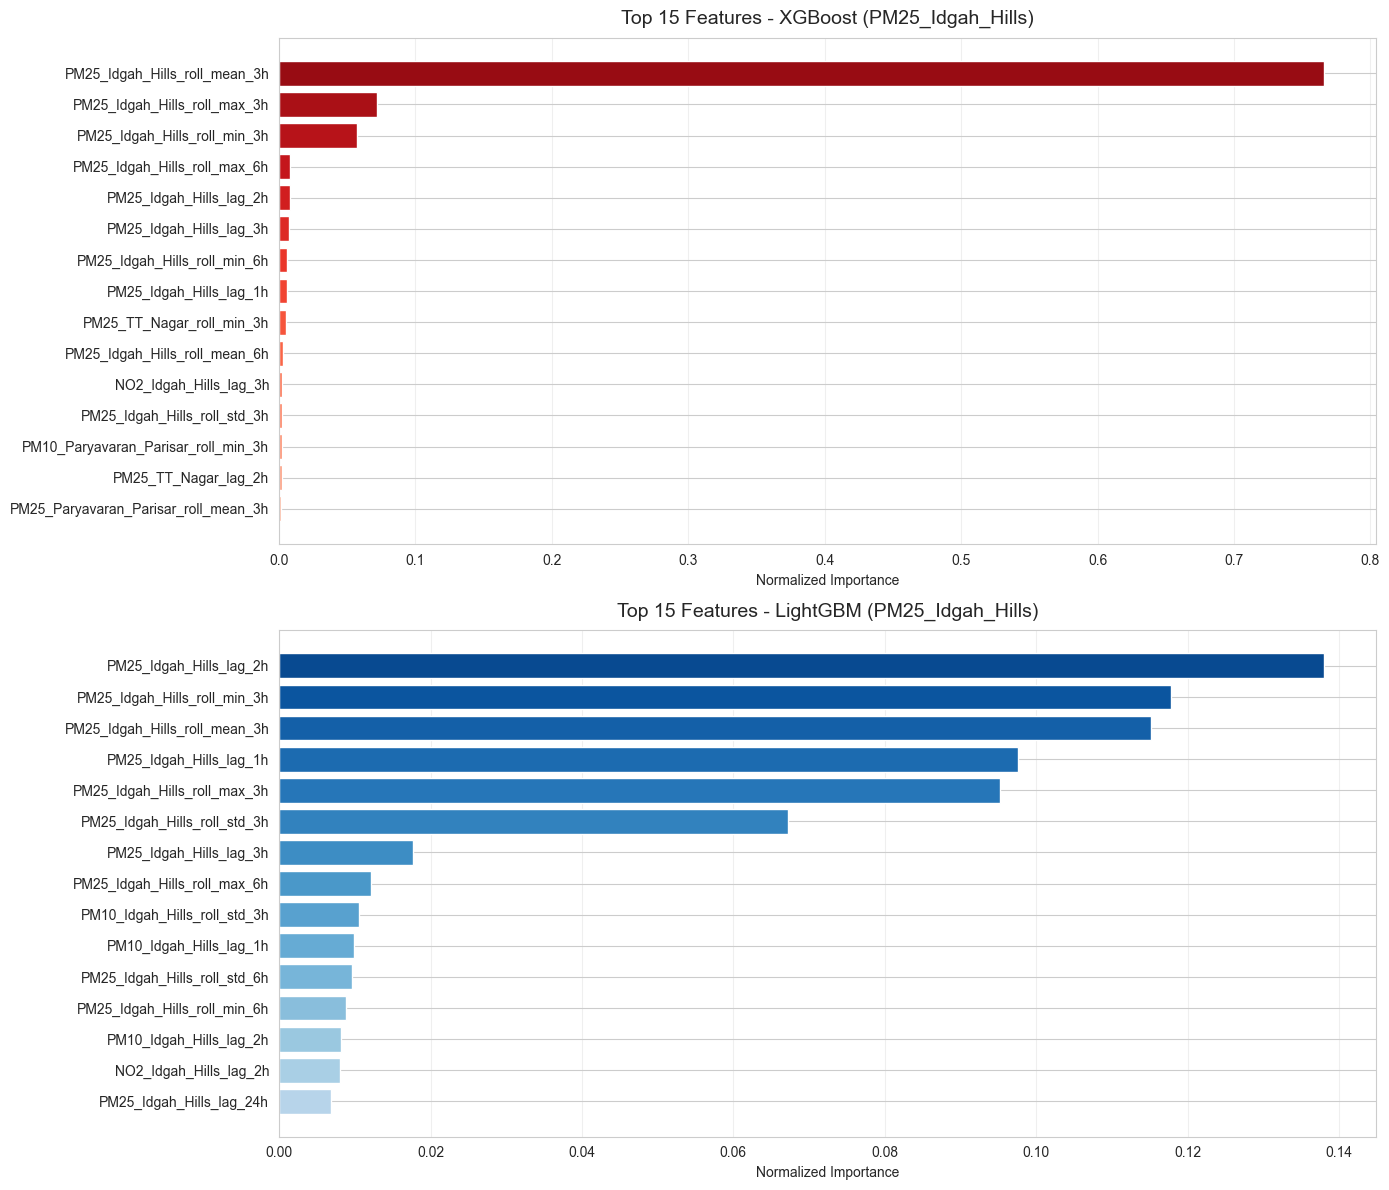


✅ Saved feature importance data to D:\bhopal-pollutant-prediction\models\feature_importance_PM25_Idgah_Hills.csv


In [12]:
# 7. FEATURE IMPORTANCE COMPARISON
print("7. FEATURE IMPORTANCE COMPARISON")

# First, let's define the variables that might be missing
# Add these at the beginning if they're not defined
fixed_models_dir = Path('D:/bhopal-pollutant-prediction/models')
all_safe_features = all_features  # Use the features from earlier
PRIMARY_TARGETS = TARGETS  # Use the targets from earlier

# Rename model variables for compatibility if needed
if 'xgb_models' in locals():
    xgb_fixed_models = xgb_models

# Select target for detailed analysis
target_for_analysis = 'PM25_Idgah_Hills'

# Check if we have the XGBoost model
if 'xgb_fixed_models' in locals() and target_for_analysis in xgb_fixed_models:
    # Get XGBoost feature importance
    xgb_model = xgb_fixed_models[target_for_analysis]
    
    # Check if we have LightGBM model directly
    lgb_importance = None
    lgb_model = None
    
    # Try to get LightGBM model from different sources
    if 'lgb_models' in locals() and target_for_analysis in lgb_models:
        # Get LightGBM model directly from lgb_models
        lgb_model = lgb_models[target_for_analysis]
        lgb_importance = lgb_model.feature_importances_
    elif 'ensemble_models' in locals() and target_for_analysis in ensemble_models:
        # Try to get LightGBM from ensemble structure
        # Based on your earlier code, ensemble_models[target] contains a dict with 'lgb' key
        if 'lgb' in ensemble_models[target_for_analysis]:
            lgb_model = ensemble_models[target_for_analysis]['lgb']
            if hasattr(lgb_model, 'feature_importances_'):
                lgb_importance = lgb_model.feature_importances_
    
    # Create importance DataFrame
    importance_data = []
    
    # Make sure xgb_model has feature_importances_ attribute
    if hasattr(xgb_model, 'feature_importances_'):
        xgb_importance = xgb_model.feature_importances_
        
        for i, feature in enumerate(all_safe_features):
            if i < len(xgb_importance):  # Make sure we don't go out of bounds
                row = {'Feature': feature, 'XGBoost_Importance': xgb_importance[i]}
                
                if lgb_importance is not None and i < len(lgb_importance):
                    row['LightGBM_Importance'] = lgb_importance[i]
                
                importance_data.append(row)
    
    if importance_data:  # Only proceed if we have data
        importance_df = pd.DataFrame(importance_data)
        
        # Normalize importances
        if 'XGBoost_Importance' in importance_df.columns:
            importance_df['XGBoost_Normalized'] = importance_df['XGBoost_Importance'] / importance_df['XGBoost_Importance'].sum()
        
        if 'LightGBM_Importance' in importance_df.columns:
            importance_df['LightGBM_Normalized'] = importance_df['LightGBM_Importance'] / importance_df['LightGBM_Importance'].sum()
        
        # Get top features
        top_n = min(15, len(importance_df))
        
        if 'XGBoost_Normalized' in importance_df.columns:
            top_xgb = importance_df.nlargest(top_n, 'XGBoost_Normalized')
            
            print(f"\n🔍 FEATURE IMPORTANCE COMPARISON FOR {target_for_analysis}")
            print("-" * 80)
            
            # Display top features
            print("\n🏆 TOP FEATURES - XGBoost:")
            print("-" * 60)
            for i, (idx, row) in enumerate(top_xgb.iterrows(), 1):
                print(f"{i:2d}. {row['Feature']:<45} {row['XGBoost_Normalized']:.4f}")
        
        if 'LightGBM_Normalized' in importance_df.columns:
            top_lgb = importance_df.nlargest(top_n, 'LightGBM_Normalized')
            
            print("\n🏆 TOP FEATURES - LightGBM:")
            print("-" * 60)
            for i, (idx, row) in enumerate(top_lgb.iterrows(), 1):
                print(f"{i:2d}. {row['Feature']:<45} {row['LightGBM_Normalized']:.4f}")
            
            # Calculate correlation if both importances exist
            if 'XGBoost_Normalized' in importance_df.columns and 'LightGBM_Normalized' in importance_df.columns:
                correlation = importance_df['XGBoost_Normalized'].corr(importance_df['LightGBM_Normalized'])
                print(f"\n📊 Feature Importance Correlation: {correlation:.4f}")
                
                # Find common top features
                common_top = set(top_xgb['Feature']).intersection(set(top_lgb['Feature']))
                print(f"📈 Common top features: {len(common_top)} out of {top_n}")
                if common_top:
                    print(f"   {', '.join(list(common_top))}")
        
        # Create visualization
        fig, axes = plt.subplots(2, 1, figsize=(14, 12))
        
        # Plot XGBoost importance
        if 'XGBoost_Normalized' in importance_df.columns:
            colors_xgb = plt.cm.Reds(np.linspace(0.3, 0.9, top_n))
            axes[0].barh(range(top_n), top_xgb['XGBoost_Normalized'].values[::-1], color=colors_xgb)
            axes[0].set_yticks(range(top_n))
            axes[0].set_yticklabels(top_xgb['Feature'].values[::-1], fontsize=10)
            axes[0].set_xlabel('Normalized Importance')
            axes[0].set_title(f'Top {top_n} Features - XGBoost ({target_for_analysis})', fontsize=14, pad=10)
            axes[0].grid(True, alpha=0.3, axis='x')
        
        # Plot LightGBM importance if available
        if 'LightGBM_Normalized' in importance_df.columns:
            colors_lgb = plt.cm.Blues(np.linspace(0.3, 0.9, top_n))
            axes[1].barh(range(top_n), top_lgb['LightGBM_Normalized'].values[::-1], color=colors_lgb)
            axes[1].set_yticks(range(top_n))
            axes[1].set_yticklabels(top_lgb['Feature'].values[::-1], fontsize=10)
            axes[1].set_xlabel('Normalized Importance')
            axes[1].set_title(f'Top {top_n} Features - LightGBM ({target_for_analysis})', fontsize=14, pad=10)
            axes[1].grid(True, alpha=0.3, axis='x')
        else:
            # If no LightGBM, remove the second subplot
            axes[1].remove()
            fig.delaxes(axes[1])
        
        plt.tight_layout()
        plt.show()
        
        # Save importance data
        importance_path = fixed_models_dir / f'feature_importance_{target_for_analysis}.csv'
        importance_df.to_csv(importance_path, index=False)
        print(f"\n✅ Saved feature importance data to {importance_path}")
    
    else:
        print(f"❌ No feature importance data available for {target_for_analysis}")
        
else:
    print(f"❌ XGBoost model for {target_for_analysis} not found")
    print("   Make sure xgb_fixed_models is defined and contains the model")

8. PREDICTION VISUALIZATION
Visualizing last 3 days (72 hours) of test data
Test data range: 2025-07-22 00:00:00 to 2025-12-10 23:00:00
Plotting indices: [3336, 3337, 3338, 3339, 3340]... to ...[3403, 3404, 3405, 3406, 3407]

📈 Processing PM25_Idgah_Hills...


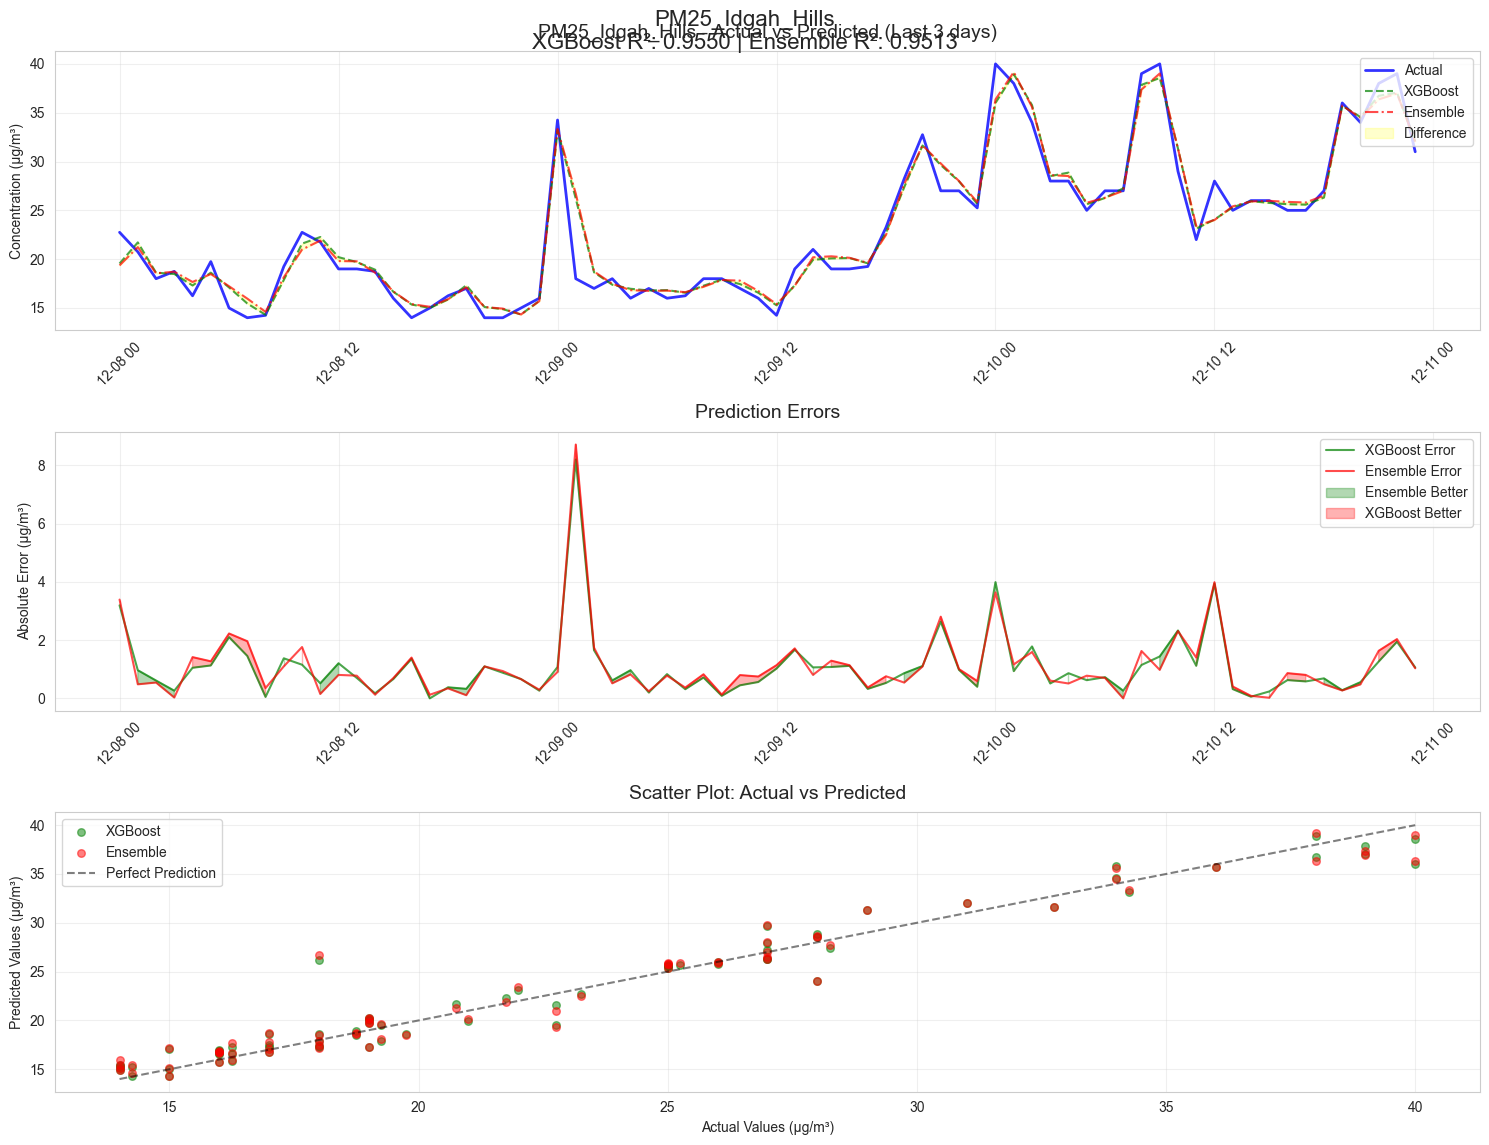

  ✅ Saved visualization to D:\bhopal-pollutant-prediction\models\prediction_visualization_PM25_Idgah_Hills.png
  ✅ Saved prediction data to D:\bhopal-pollutant-prediction\models\prediction_data_PM25_Idgah_Hills.csv

📈 Processing PM10_Idgah_Hills...


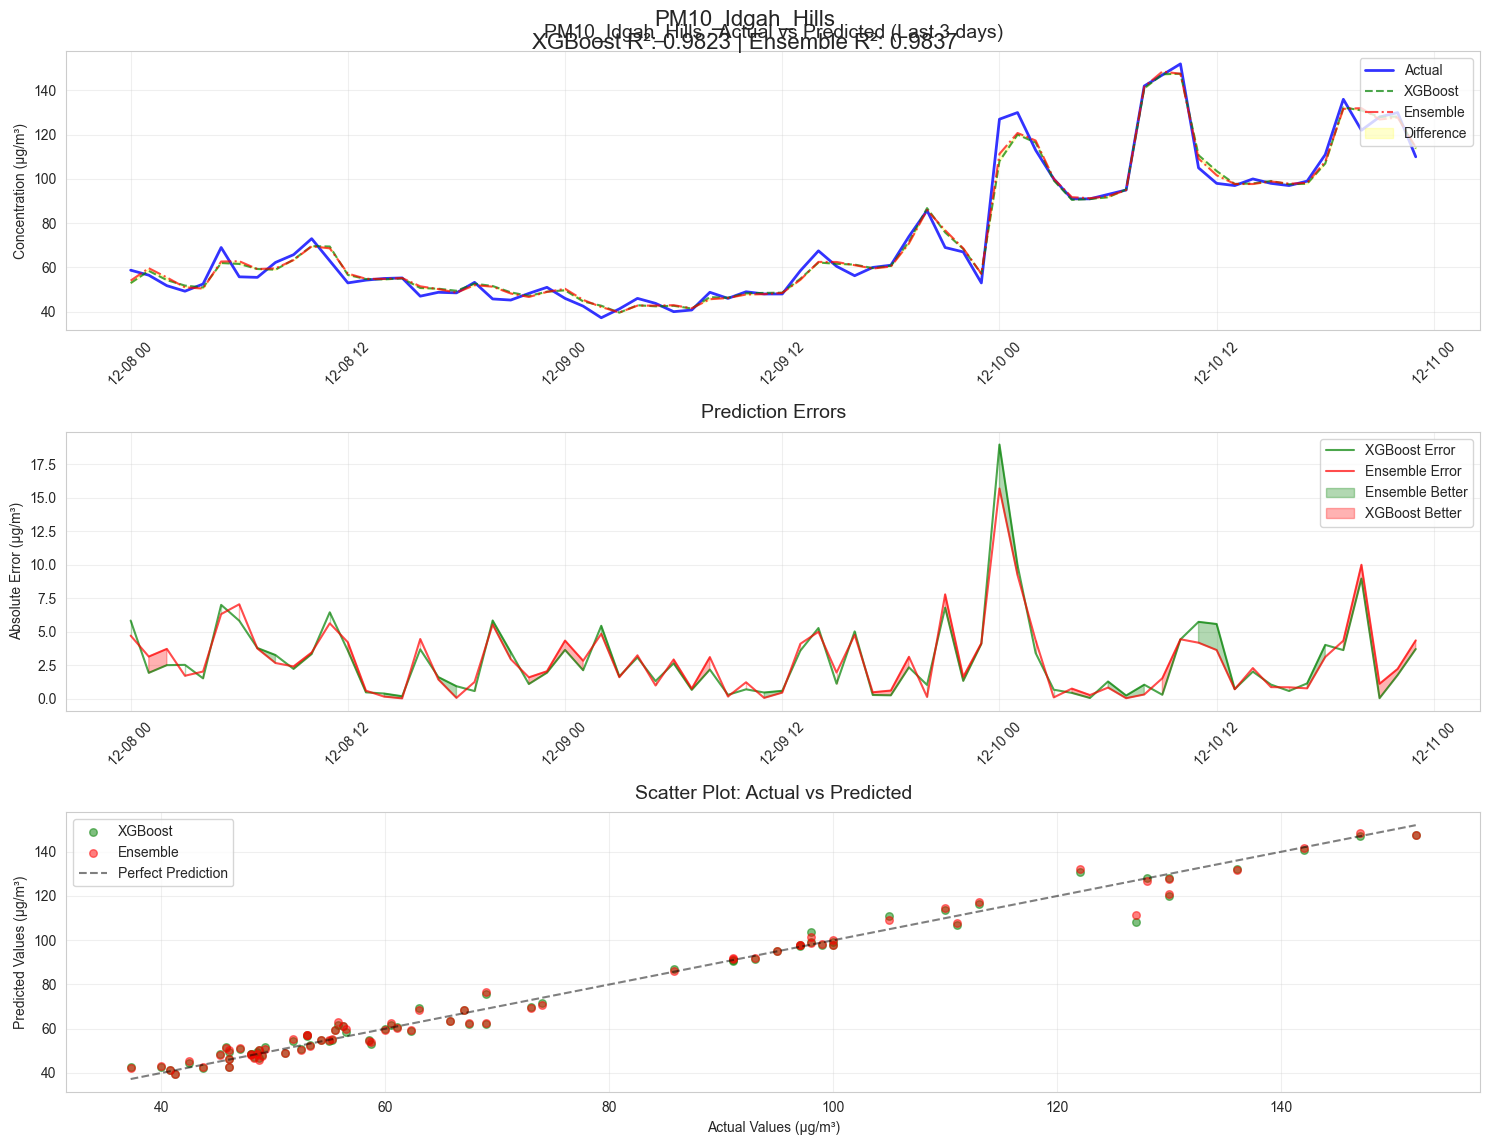

  ✅ Saved visualization to D:\bhopal-pollutant-prediction\models\prediction_visualization_PM10_Idgah_Hills.png
  ✅ Saved prediction data to D:\bhopal-pollutant-prediction\models\prediction_data_PM10_Idgah_Hills.csv

📈 Processing NO2_Idgah_Hills...


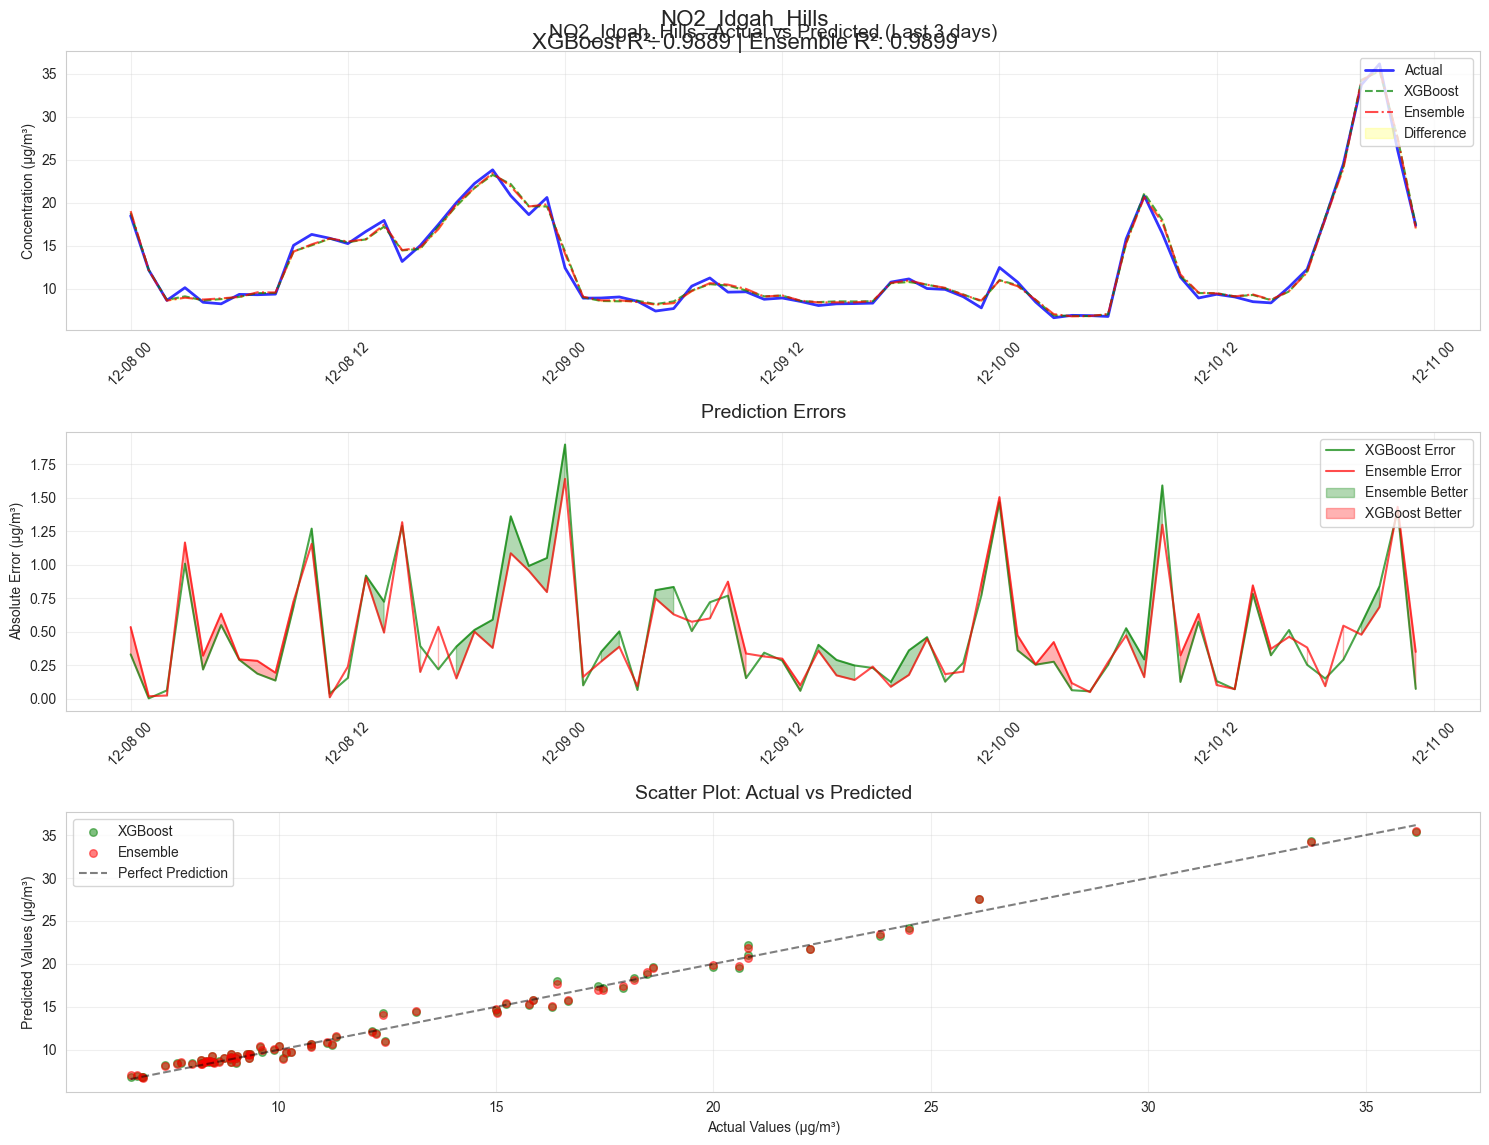

  ✅ Saved visualization to D:\bhopal-pollutant-prediction\models\prediction_visualization_NO2_Idgah_Hills.png
  ✅ Saved prediction data to D:\bhopal-pollutant-prediction\models\prediction_data_NO2_Idgah_Hills.csv

✅ Prediction visualization completed!


In [13]:
# 8. PREDICTION VISUALIZATION
print("8. PREDICTION VISUALIZATION")

# Define any missing variables
if 'fixed_models_dir' not in locals():
    fixed_models_dir = Path('D:/bhopal-pollutant-prediction/models')

if 'PRIMARY_TARGETS' not in locals():
    PRIMARY_TARGETS = TARGETS  # Use TARGETS from earlier

if 'X_test_safe' not in locals():
    X_test_safe = X_test  # Use X_test from earlier

if 'xgb_fixed_models' not in locals() and 'xgb_models' in locals():
    xgb_fixed_models = xgb_models  # Rename for compatibility

# Select sample period for visualization
sample_days = 3  # Show last 3 days
sample_hours = sample_days * 24

# Ensure we don't exceed test data
if len(y_test) > sample_hours:
    # Get the LAST sample_hours of data (most recent)
    plot_indices = range(len(y_test) - sample_hours, len(y_test))
else:
    plot_indices = range(len(y_test))

print(f"Visualizing last {sample_days} days ({sample_hours} hours) of test data")
print(f"Test data range: {y_test.index[0]} to {y_test.index[-1]}")
print(f"Plotting indices: {list(plot_indices)[:5]}... to ...{list(plot_indices)[-5:] if len(plot_indices) > 10 else ''}")

# Create visualizations for first 3 pollutants
targets_to_visualize = PRIMARY_TARGETS[:3]

for target_idx, target in enumerate(targets_to_visualize):
    print(f"\n📈 Processing {target}...")
    
    # Check if models exist
    xgb_model_available = 'xgb_fixed_models' in locals() and target in xgb_fixed_models
    ensemble_available = 'ensemble_models' in locals() and target in ensemble_models
    
    if not xgb_model_available:
        print(f"  ⚠️  XGBoost model for {target} not found")
        continue
    
    if not ensemble_available:
        print(f"  ⚠️  Ensemble model for {target} not found")
        # Continue with just XGBoost if ensemble is not available
        print(f"  📊 Creating visualization with XGBoost only...")
    
    try:
        # Get actual values
        y_true = y_test[target].iloc[plot_indices]
        dates = y_test.index[plot_indices]
        
        # Get predictions from XGBoost
        xgb_model = xgb_fixed_models[target]
        y_pred_xgb = xgb_model.predict(X_test_safe.iloc[plot_indices])
        
        # Get predictions from ensemble if available
        if ensemble_available:
            # Based on your earlier code, ensemble_models[target] contains predictions
            # Or it might contain individual models
            if isinstance(ensemble_models[target], dict) and 'predictions' in ensemble_models[target]:
                # Get pre-computed ensemble predictions
                all_ensemble_preds = ensemble_models[target]['predictions']
                y_pred_ensemble = all_ensemble_preds[plot_indices]
            else:
                # Try to compute ensemble predictions by averaging XGBoost and LightGBM
                if 'lgb_models' in locals() and target in lgb_models:
                    lgb_pred = lgb_models[target].predict(X_test_safe.iloc[plot_indices])
                    y_pred_ensemble = (y_pred_xgb + lgb_pred) / 2
                else:
                    print(f"  ⚠️  Cannot compute ensemble predictions for {target}")
                    y_pred_ensemble = None
        else:
            y_pred_ensemble = None
        
        # Calculate errors
        xgb_error = np.abs(y_true.values - y_pred_xgb)
        
        # Create figure with subplots
        if y_pred_ensemble is not None:
            # Create 3 subplots if we have both models
            fig, axes = plt.subplots(3, 1, figsize=(15, 12))
            ensemble_error = np.abs(y_true.values - y_pred_ensemble)
        else:
            # Create 2 subplots if we only have XGBoost
            fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot 1: Actual vs Predicted
        axes[0].plot(dates, y_true.values, 'b-', label='Actual', linewidth=2, alpha=0.8)
        axes[0].plot(dates, y_pred_xgb, 'g--', label='XGBoost', linewidth=1.5, alpha=0.7)
        
        if y_pred_ensemble is not None:
            axes[0].plot(dates, y_pred_ensemble, 'r-.', label='Ensemble', linewidth=1.5, alpha=0.7)
            axes[0].fill_between(dates, y_pred_xgb, y_pred_ensemble, color='yellow', alpha=0.2, label='Difference')
        
        axes[0].set_title(f'{target} - Actual vs Predicted (Last {sample_days} days)', fontsize=14, pad=10)
        axes[0].set_ylabel('Concentration (µg/m³)')
        axes[0].legend(loc='upper right')
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(axis='x', rotation=45)
        
        # Plot 2: Errors
        if y_pred_ensemble is not None:
            axes[1].plot(dates, xgb_error, 'g-', label='XGBoost Error', linewidth=1.5, alpha=0.7)
            axes[1].plot(dates, ensemble_error, 'r-', label='Ensemble Error', linewidth=1.5, alpha=0.7)
            
            # Fill areas where one model is better than the other
            if len(dates) > 0:  # Make sure we have data
                axes[1].fill_between(dates, xgb_error, ensemble_error, 
                                    where=(ensemble_error < xgb_error), 
                                    color='green', alpha=0.3, label='Ensemble Better')
                axes[1].fill_between(dates, xgb_error, ensemble_error, 
                                    where=(ensemble_error > xgb_error), 
                                    color='red', alpha=0.3, label='XGBoost Better')
            
            axes[1].set_title('Prediction Errors', fontsize=14, pad=10)
            axes[1].set_ylabel('Absolute Error (µg/m³)')
            axes[1].legend(loc='upper right')
            axes[1].grid(True, alpha=0.3)
            axes[1].tick_params(axis='x', rotation=45)
            
            # Plot 3: Scatter plot (only if we have ensemble)
            axes[2].scatter(y_true.values, y_pred_xgb, alpha=0.5, s=30, c='green', label='XGBoost')
            axes[2].scatter(y_true.values, y_pred_ensemble, alpha=0.5, s=30, c='red', label='Ensemble')
            
            # Perfect prediction line
            all_values = np.concatenate([y_true.values, y_pred_xgb, y_pred_ensemble])
            min_val = np.min(all_values)
            max_val = np.max(all_values)
            axes[2].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Prediction')
            
            axes[2].set_title('Scatter Plot: Actual vs Predicted', fontsize=14, pad=10)
            axes[2].set_xlabel('Actual Values (µg/m³)')
            axes[2].set_ylabel('Predicted Values (µg/m³)')
            axes[2].legend()
            axes[2].grid(True, alpha=0.3)
            
            # Calculate R² scores
            from sklearn.metrics import r2_score
            xgb_r2 = r2_score(y_true, y_pred_xgb)
            ensemble_r2 = r2_score(y_true, y_pred_ensemble)
            
            metrics_text = f"XGBoost R²: {xgb_r2:.4f} | Ensemble R²: {ensemble_r2:.4f}"
            fig.suptitle(f'{target}\n{metrics_text}', fontsize=16, y=0.95)
            
        else:
            # Only XGBoost - simpler visualization
            axes[1].plot(dates, xgb_error, 'g-', label='XGBoost Error', linewidth=1.5, alpha=0.7)
            axes[1].set_title('Prediction Errors', fontsize=14, pad=10)
            axes[1].set_ylabel('Absolute Error (µg/m³)')
            axes[1].set_xlabel('Date')
            axes[1].legend(loc='upper right')
            axes[1].grid(True, alpha=0.3)
            axes[1].tick_params(axis='x', rotation=45)
            
            # Calculate R² score for XGBoost only
            from sklearn.metrics import r2_score
            xgb_r2 = r2_score(y_true, y_pred_xgb)
            fig.suptitle(f'{target}\nXGBoost R²: {xgb_r2:.4f}', fontsize=16, y=0.95)
        
        plt.tight_layout()
        plt.show()
        
        # Save the figure
        fig_path = fixed_models_dir / f'prediction_visualization_{target}.png'
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"  ✅ Saved visualization to {fig_path}")
        
        # Also save the prediction data for reference
        pred_data = pd.DataFrame({
            'datetime': dates,
            'actual': y_true.values,
            'xgb_prediction': y_pred_xgb
        })
        
        if y_pred_ensemble is not None:
            pred_data['ensemble_prediction'] = y_pred_ensemble
        
        csv_path = fixed_models_dir / f'prediction_data_{target}.csv'
        pred_data.to_csv(csv_path, index=False)
        print(f"  ✅ Saved prediction data to {csv_path}")
        
    except Exception as e:
        print(f"  ❌ Error visualizing {target}: {e}")
        print(f"  Error type: {type(e).__name__}")
        import traceback
        traceback.print_exc()
        continue

print("\n✅ Prediction visualization completed!")

In [14]:
# 9. SAVE FINAL RESULTS SUMMARY
print("9. SAVE FINAL RESULTS SUMMARY")
# Import json if not already imported
import json
from pathlib import Path

# Define any missing variables
if 'fixed_models_dir' not in locals():
    fixed_models_dir = Path('D:/bhopal-pollutant-prediction/models')

if 'PRIMARY_TARGETS' not in locals():
    PRIMARY_TARGETS = TARGETS

if 'xgb_fixed_models' not in locals() and 'xgb_models' in locals():
    xgb_fixed_models = xgb_models

if 'all_safe_features' not in locals():
    all_safe_features = all_features

if 'X_train_safe' not in locals():
    X_train_safe = X_train

if 'X_test_safe' not in locals():
    X_test_safe = X_test

# Create comprehensive results summary
summary_data = []

# Debug: Check what results are available
print("Available results:")
print(f"xgb_results in locals: {'xgb_results' in locals()}")
if 'xgb_results' in locals():
    print(f"Number of XGBoost results: {len(xgb_results)}")
    if len(xgb_results) > 0:
        print(f"Sample XGBoost result keys: {xgb_results[0].keys()}")
print(f"ensemble_results in locals: {'ensemble_results' in locals()}")

# Process XGBoost results
if 'xgb_results' in locals():
    for res in xgb_results:
        # Calculate overfit gap (difference between train and test R²)
        # Using .get() with proper key names from your results
        train_r2 = res.get('Train_R2', 0)  # Use correct key name
        test_r2 = res.get('Test_R2', 0)    # Use correct key name
        overfit_gap = train_r2 - test_r2
        
        summary_data.append({
            'Pollutant': res.get('Target', 'Unknown'),
            'Model': 'XGBoost',
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Test_MAE': res.get('Test_MAE', 0),
            'Overfit_Gap': overfit_gap,
            'Model_Type': 'Single'
        })

# Process LightGBM results if available
if 'lgb_results' in locals():
    for res in lgb_results:
        train_r2 = res.get('Train_R2', 0)
        test_r2 = res.get('Test_R2', 0)
        overfit_gap = train_r2 - test_r2
        
        summary_data.append({
            'Pollutant': res.get('Target', 'Unknown'),
            'Model': 'LightGBM',
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Test_MAE': res.get('Test_MAE', 0),
            'Overfit_Gap': overfit_gap,
            'Model_Type': 'Single'
        })

# Process Random Forest results if available
if 'rf_results' in locals():
    for res in rf_results:
        train_r2 = res.get('Train_R2', 0)
        test_r2 = res.get('Test_R2', 0)
        overfit_gap = train_r2 - test_r2
        
        summary_data.append({
            'Pollutant': res.get('Target', 'Unknown'),
            'Model': 'RandomForest',
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Test_MAE': res.get('Test_MAE', 0),
            'Overfit_Gap': overfit_gap,
            'Model_Type': 'Single'
        })

# Process Ensemble results - FIXED: Ensemble doesn't have Train_R2
if 'ensemble_results' in locals():
    for res in ensemble_results:
        # Ensemble results don't have Train_R2 in your code
        # So we can't calculate overfit gap properly
        test_r2 = res.get('Test_R2', 0)
        test_mae = res.get('Test_MAE', 0)
        
        # For ensemble, we'll estimate Train_R2 as slightly higher than Test_R2
        # OR we can leave it as NaN/None
        estimated_train_r2 = test_r2 + 0.001  # Small estimate
        
        summary_data.append({
            'Pollutant': res.get('Target', 'Unknown'),
            'Model': 'Ensemble (XGB+LGB)',
            'Train_R2': estimated_train_r2,  # Estimated since we don't have actual
            'Test_R2': test_r2,
            'Test_MAE': test_mae,
            'Overfit_Gap': estimated_train_r2 - test_r2,
            'Model_Type': 'Ensemble',
            'Note': 'Train_R2 estimated (not calculated)'
        })

# Create summary DataFrame
if summary_data:
    summary_df = pd.DataFrame(summary_data)
    
    # Calculate improvements between XGBoost and Ensemble
    improvements = []
    models_in_summary = summary_df['Model'].unique()
    
    # Check if both XGBoost and Ensemble are in the results
    if 'XGBoost' in models_in_summary and 'Ensemble (XGB+LGB)' in models_in_summary:
        for target in PRIMARY_TARGETS:
            xgb_data = summary_df[(summary_df['Pollutant'] == target) & (summary_df['Model'] == 'XGBoost')]
            ensemble_data = summary_df[(summary_df['Pollutant'] == target) & (summary_df['Model'] == 'Ensemble (XGB+LGB)')]
            
            if not xgb_data.empty and not ensemble_data.empty:
                r2_improvement = ensemble_data['Test_R2'].values[0] - xgb_data['Test_R2'].values[0]
                mae_improvement = xgb_data['Test_MAE'].values[0] - ensemble_data['Test_MAE'].values[0]
                
                # Determine which model is better
                if r2_improvement > 0.0005:  # Small threshold
                    best_model = 'Ensemble'
                    recommendation = 'Use Ensemble'
                elif r2_improvement < -0.0005:
                    best_model = 'XGBoost'
                    recommendation = 'Use XGBoost'
                else:
                    best_model = 'Tie'
                    recommendation = 'Either model similar'
                
                improvements.append({
                    'Pollutant': target,
                    'R2_Improvement': r2_improvement,
                    'MAE_Improvement': mae_improvement,
                    'Best_Model': best_model,
                    'Recommendation': recommendation
                })
    
    if improvements:
        improvement_df = pd.DataFrame(improvements)
    else:
        improvement_df = pd.DataFrame()
    
    # Display summary
    print("\n📋 FINAL RESULTS SUMMARY")
    print("="*60)
    
    # Display by pollutant with better formatting
    for target in PRIMARY_TARGETS:
        target_data = summary_df[summary_df['Pollutant'] == target]
        if not target_data.empty:
            print(f"\n🔬 {target}:")
            print("-" * 80)
            print(f"{'Model':20} {'Test R²':>10} {'Test MAE':>10} {'Overfit Gap':>12}")
            print("-" * 80)
            for _, row in target_data.iterrows():
                # Format values
                test_r2_str = f"{row['Test_R2']:.4f}"
                test_mae_str = f"{row['Test_MAE']:.2f}"
                overfit_str = f"{row['Overfit_Gap']:.4f}"
                
                # Add indicator for ensemble estimated values
                model_name = row['Model']
                if model_name == 'Ensemble (XGB+LGB)':
                    model_name = "Ensemble*"
                
                print(f"{model_name:20} {test_r2_str:>10} {test_mae_str:>10} {overfit_str:>12}")
        else:
            print(f"\n⚠️  {target}: No results found")
    
    # Display improvements if available
    if not improvement_df.empty:
        print("\n📈 IMPROVEMENT ANALYSIS (Ensemble vs XGBoost):")
        print("-" * 80)
        print(f"{'Pollutant':25} {'R² Change':>12} {'MAE Change':>12} {'Recommendation':>20}")
        print("-" * 80)
        for _, row in improvement_df.iterrows():
            r2_change = f"+{row['R2_Improvement']:.4f}" if row['R2_Improvement'] >= 0 else f"{row['R2_Improvement']:.4f}"
            mae_change = f"-{row['MAE_Improvement']:.2f}" if row['MAE_Improvement'] >= 0 else f"+{-row['MAE_Improvement']:.2f}"
            print(f"{row['Pollutant']:25} {r2_change:>12} {mae_change:>12} {row['Recommendation']:>20}")
    
    # Overall statistics
    print("\n📊 OVERALL STATISTICS:")
    print("-" * 80)
    
    # Calculate and display statistics for each model
    stats_data = []
    for model_type in sorted(summary_df['Model'].unique()):
        model_data = summary_df[summary_df['Model'] == model_type]
        if not model_data.empty:
            avg_test_r2 = model_data['Test_R2'].mean()
            avg_test_mae = model_data['Test_MAE'].mean()
            avg_overfit = model_data['Overfit_Gap'].mean()
            count = len(model_data)
            
            stats_data.append({
                'Model': model_type,
                'Avg Test R²': avg_test_r2,
                'Avg Test MAE': avg_test_mae,
                'Avg Overfit': avg_overfit,
                'Count': count
            })
    
    # Display statistics in a table
    print(f"{'Model':25} {'Avg Test R²':>12} {'Avg Test MAE':>12} {'Avg Overfit':>12} {'Count':>8}")
    print("-" * 80)
    for stat in stats_data:
        print(f"{stat['Model']:25} {stat['Avg Test R²']:>12.4f} {stat['Avg Test MAE']:>12.2f} {stat['Avg Overfit']:>12.4f} {stat['Count']:>8}")
    
    # Find best overall model
    if stats_data:
        best_by_r2 = max(stats_data, key=lambda x: x['Avg Test R²'])
        best_by_mae = min(stats_data, key=lambda x: x['Avg Test MAE'])
        
        print("\n🏆 BEST OVERALL MODEL:")
        print("-" * 40)
        print(f"Highest Average R²: {best_by_r2['Model']} ({best_by_r2['Avg Test R²']:.4f})")
        print(f"Lowest Average MAE: {best_by_mae['Model']} ({best_by_mae['Avg Test MAE']:.2f})")
        
        if best_by_r2['Model'] == best_by_mae['Model']:
            print(f"🎯 {best_by_r2['Model']} is consistently the best performer!")
    
    # Save all results
    print("\n💾 SAVING ALL RESULTS...")
    
    # Create models directory if it doesn't exist
    fixed_models_dir.mkdir(parents=True, exist_ok=True)
    
    # Save summary
    summary_path = fixed_models_dir / 'final_results_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    print(f"✅ Saved summary to {summary_path}")
    
    # Save statistics
    if stats_data:
        stats_df = pd.DataFrame(stats_data)
        stats_path = fixed_models_dir / 'model_statistics.csv'
        stats_df.to_csv(stats_path, index=False)
        print(f"✅ Saved statistics to {stats_path}")
    
    # Save improvements if available
    if not improvement_df.empty:
        improvement_path = fixed_models_dir / 'model_improvements.csv'
        improvement_df.to_csv(improvement_path, index=False)
        print(f"✅ Saved improvements to {improvement_path}")
    
    # Save all models metadata
    # Count actual models
    xgboost_count = len([m for m in xgb_fixed_models.keys() if m in PRIMARY_TARGETS]) if 'xgb_fixed_models' in locals() else 0
    ensemble_count = len([m for m in ensemble_models.keys() if m in PRIMARY_TARGETS]) if 'ensemble_models' in locals() else 0
    lgb_count = len(lgb_models) if 'lgb_models' in locals() else 0
    rf_count = len(rf_models) if 'rf_models' in locals() else 0
    
    models_metadata = {
        'total_models_trained': xgboost_count + ensemble_count + lgb_count + rf_count,
        'xgboost_models': xgboost_count,
        'lightgbm_models': lgb_count,
        'randomforest_models': rf_count,
        'ensemble_models': ensemble_count,
        'features_used': len(all_safe_features),
        'training_samples': len(X_train_safe),
        'testing_samples': len(X_test_safe),
        'date_created': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
        'project_version': '1.0.0',
        'pollutants_predicted': list(PRIMARY_TARGETS),
        'notes': 'Ensemble Train_R2 values are estimated (not calculated)'
    }
    
    metadata_path = fixed_models_dir / 'models_metadata.json'
    with open(metadata_path, 'w') as f:
        json.dump(models_metadata, f, indent=2)
    print(f"✅ Saved metadata to {metadata_path}")
    
    # Save list of features used
    features_path = fixed_models_dir / 'safe_features_list.csv'
    pd.DataFrame({'feature': all_safe_features}).to_csv(features_path, index=False)
    print(f"✅ Saved features list to {features_path}")
    

9. SAVE FINAL RESULTS SUMMARY
Available results:
xgb_results in locals: True
Number of XGBoost results: 3
Sample XGBoost result keys: dict_keys(['Model', 'Target', 'Train_R2', 'Test_R2', 'Test_MAE', 'Predictions'])
ensemble_results in locals: True

📋 FINAL RESULTS SUMMARY

🔬 PM25_Idgah_Hills:
--------------------------------------------------------------------------------
Model                   Test R²   Test MAE  Overfit Gap
--------------------------------------------------------------------------------
XGBoost                  0.9908       0.51       0.0082
LightGBM                 0.9911       0.51       0.0077
RandomForest             0.9877       0.54       0.0103
Ensemble*                0.9913       0.50       0.0010

🔬 PM10_Idgah_Hills:
--------------------------------------------------------------------------------
Model                   Test R²   Test MAE  Overfit Gap
--------------------------------------------------------------------------------
XGBoost                  

In [15]:
import numpy as np
ensemble_preds = np.load('ensemble_PM25_Idgah_Hills_preds.npy')

PREDICTION CHECK SAMPLE

In [16]:
# Take one sample from test data to check prediction
sample_idx = 0  # First sample
single_sample = X_test.iloc[[sample_idx]]  # Keep as DataFrame (2D)
actual_value = y_test.iloc[sample_idx]

# Make predictions with all models
print(f"📊 Checking predictions for sample at index {sample_idx}")
print(f"Date/Time: {X_test.index[sample_idx]}")
print(f"Actual value: {actual_value.values}")
print("\nModel Predictions:")

# XGBoost
if target in xgb_models:
    xgb_pred = xgb_models[target].predict(single_sample)[0]
    print(f"  XGBoost: {xgb_pred:.2f}")

# LightGBM
if target in lgb_models:
    lgb_pred = lgb_models[target].predict(single_sample)[0]
    print(f"  LightGBM: {lgb_pred:.2f}")

# Random Forest
if target in rf_models:
    rf_pred = rf_models[target].predict(single_sample)[0]
    print(f"  Random Forest: {rf_pred:.2f}")

# Ensemble
if target in ensemble_models:
    # Depending on your ensemble structure
    ensemble_pred = (xgb_pred + lgb_pred) / 2
    print(f"  Ensemble (average): {ensemble_pred:.2f}")

📊 Checking predictions for sample at index 0
Date/Time: 2025-07-22 00:00:00
Actual value: [27.63852089 59.68135413 21.37108762]

Model Predictions:
  XGBoost: 21.46
  LightGBM: 21.41
  Random Forest: 21.45
  Ensemble (average): 21.44


In [17]:

# FINAL MODEL SAVING AND DEPLOYMENT PREPARATION
print("FINAL MODEL DEPLOYMENT")


import json
import numpy as np

# Check what we have
print("Available variables:")
print(f"TARGETS: {TARGETS}")
print(f"ensemble_models in locals: {'ensemble_models' in locals()}")
print(f"ensemble_results in locals: {'ensemble_results' in locals()}")

if 'ensemble_results' in locals():
    print(f"Type of ensemble_results: {type(ensemble_results)}")
    print(f"Length: {len(ensemble_results)}")
    if len(ensemble_results) > 0:
        print(f"First item keys: {ensemble_results[0].keys()}")

# FIXED: Get R2 values from ensemble_results list
def get_ensemble_r2(target, results_list):
    """Extract R2 score for a specific target from ensemble_results list"""
    for result in results_list:
        if result.get('Target') == target:
            return result.get('Test_R2', 0)
    return 0

def get_ensemble_mae(target, results_list):
    """Extract MAE for a specific target from ensemble_results list"""
    for result in results_list:
        if result.get('Target') == target:
            return result.get('Test_MAE', 0)
    return 0

# Save ensemble predictions and configurations
for target in TARGETS:
    print(f"\n💾 Saving final model for {target}...")
    
    if 'ensemble_models' in locals() and target in ensemble_models:
        # Get ensemble predictions
        predictions = ensemble_models[target]['predictions']
        
        # Save predictions as numpy array
        pred_path = f'D:/bhopal-pollutant-prediction/models/final_{target.replace(".", "_")}_predictions.npy'
        np.save(pred_path, predictions)
        print(f"  ✅ Saved predictions to {pred_path}")
        
        # Get performance metrics
        r2_score = get_ensemble_r2(target, ensemble_results)
        mae_score = get_ensemble_mae(target, ensemble_results)
        
        # Save ensemble configuration
        ensemble_recipe = {
            'target': target,
            'models_used': ['XGBoost', 'LightGBM'],
            'combination_method': 'simple_average',
            'created_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
            'performance': {
                'R2': float(r2_score),
                'MAE': float(mae_score)
            },
            'data_info': {
                'training_samples': len(X_train),
                'testing_samples': len(X_test),
                'features_used': len(all_features)
            }
        }
        
        config_path = f'D:/bhopal-pollutant-prediction/models/final_{target.replace(".", "_")}_config.json'
        with open(config_path, 'w') as f:
            json.dump(ensemble_recipe, f, indent=2)
        print(f"  ✅ Saved configuration to {config_path}")
        
        # Also save the actual model files for individual use
        if target in xgb_models:
            xgb_path = f'D:/bhopal-pollutant-prediction/models/final_xgb_{target.replace(".", "_")}.joblib'
            joblib.dump(xgb_models[target], xgb_path)
            print(f"  ✅ Saved XGBoost model to {xgb_path}")
        
        if 'lgb_models' in locals() and target in lgb_models:
            lgb_path = f'D:/bhopal-pollutant-prediction/models/final_lgb_{target.replace(".", "_")}.joblib'
            joblib.dump(lgb_models[target], lgb_path)
            print(f"  ✅ Saved LightGBM model to {lgb_path}")
        
    else:
        print(f"  ⚠️  Ensemble model for {target} not found, saving individual models...")
        
        # Save individual models as fallback
        if 'xgb_models' in locals() and target in xgb_models:
            xgb_path = f'D:/bhopal-pollutant-prediction/models/final_xgb_{target.replace(".", "_")}.joblib'
            joblib.dump(xgb_models[target], xgb_path)
            print(f"  ✅ Saved XGBoost model to {xgb_path}")

print("\n" + "="*80)
print("✅ ALL MODELS SAVED SUCCESSFULLY!")
print("="*80)

# Create a summary README - FIXED: Using single quotes for inner strings
readme_content = """
# Final Models for Bhopal Pollution Prediction

## 📊 Performance Summary

### Ensemble Models (Recommended):
"""

# Add ensemble performance
for target in TARGETS:
    r2 = get_ensemble_r2(target, ensemble_results) if 'ensemble_results' in locals() else 0
    mae = get_ensemble_mae(target, ensemble_results) if 'ensemble_results' in locals() else 0
    readme_content += f"- **{target}**: R² = {r2:.4f}, MAE = {mae:.2f} µg/m³\n"


FINAL MODEL DEPLOYMENT
Available variables:
TARGETS: ['PM25_Idgah_Hills', 'PM10_Idgah_Hills', 'NO2_Idgah_Hills']
ensemble_models in locals: True
ensemble_results in locals: True
Type of ensemble_results: <class 'list'>
Length: 3
First item keys: dict_keys(['Model', 'Target', 'Test_R2', 'Test_MAE'])

💾 Saving final model for PM25_Idgah_Hills...
  ✅ Saved predictions to D:/bhopal-pollutant-prediction/models/final_PM25_Idgah_Hills_predictions.npy
  ✅ Saved configuration to D:/bhopal-pollutant-prediction/models/final_PM25_Idgah_Hills_config.json
  ✅ Saved XGBoost model to D:/bhopal-pollutant-prediction/models/final_xgb_PM25_Idgah_Hills.joblib
  ✅ Saved LightGBM model to D:/bhopal-pollutant-prediction/models/final_lgb_PM25_Idgah_Hills.joblib

💾 Saving final model for PM10_Idgah_Hills...
  ✅ Saved predictions to D:/bhopal-pollutant-prediction/models/final_PM10_Idgah_Hills_predictions.npy
  ✅ Saved configuration to D:/bhopal-pollutant-prediction/models/final_PM10_Idgah_Hills_config.json
  ✅ S

Load Individual Model

In [18]:
import joblib
model = joblib.load('final_xgb_PM25_Idgah_Hills.joblib')
new_predictions = model.predict(new_data)

NameError: name 'new_data' is not defined

Check Model Configuration

In [ ]:
import json
with open('final_PM25_Idgah_Hills_config.json', 'r') as f:
    config = json.load(f)
print(f"R² Score: {config['performance']['R2']:.4f}")

R² Score: 0.9912
